# Statistical Arbitrage Pipeline — Concepts & Code Explained

In this project each section explains what a phase does, why it exists (the finance/stats concept),
and how the code implements it.


#  0. Summary of main method

Statistical arbitrage (pairs trading) bets that two economically related stocks, whose
prices normally move together, will keep doing so. When they temporarily diverge, you
short the outperformer and buy the underperformer, betting the gap closes. Profit comes
from the spread reverting to its historical relationship — not from either stock going up.

The pipeline has four logical phases:


Formation — find pairs whose prices have a genuine, stable, fast-reverting relationship.
Trading — generate buy/sell signals from how far the pair has drifted from normal.
Portfolio construction — decide how much capital to put behind each pair.
Validation — check whether the whole thing is a real edge or a statistical accident.


Each phase corresponds to a real risk in quant research, and each fix you made was closing
a specific hole. That arc is worth holding onto as you read the rest of this doc.

# 1. Data Acquisition & Sector Mapping

In [1]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")

SECTOR_MAP = {
    "AAPL": "Tech", "MSFT": "Tech", "NVDA": "Tech", "INTC": "Tech", "CSCO": "Tech",
    "QCOM": "Tech", "TXN": "Tech", "AVGO": "Tech", "IBM": "Tech", "ORCL": "Tech",
    "CRM": "Tech", "ADBE": "Tech",
    "GOOGL": "Comm", "META": "Comm", "NFLX": "Comm", "DIS": "Comm", "CMCSA": "Comm",
    "AMZN": "Cons", "TSLA": "Cons", "WMT": "Cons", "COST": "Cons", "TGT": "Cons",
    "PG": "Cons_Def", "KO": "Cons_Def", "PEP": "Cons_Def",
    "JPM": "Fin", "BAC": "Fin", "WFC": "Fin", "C": "Fin", "GS": "Fin", "MS": "Fin",
    "V": "Fin", "MA": "Fin", "AXP": "Fin",
    "JNJ": "Health", "UNH": "Health", "PFE": "Health", "ABBV": "Health", "TMO": "Health", "MDT": "Health",
    "XOM": "Energy", "CVX": "Energy", "COP": "Energy", "SLB": "Energy",
    "BA": "Ind", "UNP": "Ind", "HON": "Ind", "UPS": "Ind", "CAT": "Ind", "MMM": "Ind"
}
tickers = list(SECTOR_MAP.keys())

master_data = yf.download(tickers, start="2018-01-01", end="2024-01-01", progress=False)['Close']
master_data = master_data.ffill().dropna(axis=1)

FORMATION_DAYS = 504
TRADING_DAYS = 126
CORR_THRESHOLD = 0.90
ADF_P_VALUE = 0.01
HL_CUTOFF = 30
MAX_TICKER_OVERLAP = 2

formation_data = master_data.iloc[:FORMATION_DAYS]

**Concept — why sectors matter:** two stocks can be highly correlated (move in the same direction) just because they both ride the same broad market trend, without having any real economic tether to each other. Two companies in the same sector (e.g. Visa and Mastercard) share underlying demand drivers — the same customers, the same macro exposure, sometimes literal business substitution — so a price gap between them is more likely to be "temporary noise" rather than "the market correctly repricing two unrelated things." Restricting candidate pairs to same-sector tickers is a way of encoding a genuine economic prior into the statistics, rather than trusting correlation alone.

**Concept — forward-fill vs drop:** .ffill() carries the last known price forward through missing days (holidays, data gaps) so rolling calculations don't break. .dropna(axis=1) removes any ticker that still has missing data after that (e.g., it didn't trade for the whole window) — you want a clean, fully-populated price matrix before doing any math on it.


# **2. Formation: Finding Candidate Pairs**
This is the "screening" stage — it happens only on historical (formation) data, never on the data you're about to trade, which is the single most important discipline in this whole project (more on why in Section 6).


In [2]:
# Calculate correlation on the historical 'formation' window
corr_matrix = formation_data.corr()

# Mask the upper triangle to avoid duplicate pairs
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Stack and filter for highly correlated pairs
high_corr = corr_matrix.where(mask).stack()
high_corr = high_corr[high_corr > CORR_THRESHOLD]

**Why:** Testing every possible pair for cointegration is expensive (it's an O(n²) problem — with ~50 tickers that's ~1,225 pairs, each requiring a regression + statistical test). A correlation filter is a cheap, fast way to discard obviously unrelated pairs before running the expensive test on the survivors. It's a computational shortcut, not a statistical claim — high correlation does not imply cointegration (this distinction is the crux of the whole project, explained next).


# **2b. Sector filter**

In [3]:
sector_matched_pairs = [pair for pair in high_corr.index
                        if SECTOR_MAP[pair[0]] == SECTOR_MAP[pair[1]]]

print(f"Found {len(sector_matched_pairs)} highly correlated, same-sector pairs.")

Found 10 highly correlated, same-sector pairs.


Only keep correlated pairs that are also in the same sector — combining a statistical signal (correlation) with an economic prior (shared sector) to reduce the chance of trading a coincidental relationship.

# **2c. Cointegration test (the Engle-Granger method) &  Half-life filter (Ornstein-Uhlenbeck reversion speed)**

In [4]:
results_list = []

for pair in sector_matched_pairs:
    Y_train = formation_data[pair[0]]
    X_train = sm.add_constant(formation_data[pair[1]])

    try:
        # Step 1: Regress Y on X
        model = sm.OLS(Y_train, X_train).fit()

        # Step 2: ADF Test on Residuals
        p_value = adfuller(model.resid)[1]

        if p_value < ADF_P_VALUE:
            # Step 3: OU Half-Life Estimation
            res_series = model.resid
            res_diff = res_series.diff().dropna()
            res_lag = res_series.shift(1).dropna()

            phi = sm.OLS(res_diff, res_lag).fit().params.iloc[0]

            if phi < 0: # Negative phi means mean-reverting
                half_life = -np.log(2) / phi

                if half_life < HL_CUTOFF:
                    results_list.append({
                        "Pair": pair,
                        "P-Value": p_value,
                        "Half_Life": half_life,
                        "Intercept": model.params.iloc[0],
                        "Slope": model.params.iloc[1]
                    })
    except:
        continue

**Concept —** correlation vs. cointegration, the core idea of the whole project:

Correlation measures whether two series move in the same direction at the same time. Two stocks can be highly correlated while one drifts to &#36;500 and the other to &#36;50 — correlation says nothing about the distance between them staying stable.
Cointegration means a specific linear combination of the two series is stationary — it doesn't trend away, it hovers around a fixed mean forever. This is the property you actually need for a mean-reversion trade to make sense: if the spread is stationary, then "the spread is unusually wide today" is a meaningful, exploitable statement.

How the test works, step by step:

- Regress one stock's price (Y) on the other (X) via OLS: Y = intercept + slope × X + residual. The slope here is the hedge ratio — how many dollars of X you need per dollar of Y to make a market-neutral position (see Section 4).
- The residual series is the spread — the part of Y's price not explained by X.
- Run the Augmented Dickey-Fuller (ADF) test on that residual series. The ADF test's null hypothesis is "this series has a unit root" (i.e., it's a random walk that can drift anywhere, not mean-reverting). A low p-value lets you reject that null and conclude the residual is stationary — i.e., the pair is cointegrated.

**Why p < 0.01 and not the textbook-standard 0.05:** you are testing many pairs simultaneously (every epoch, across dozens of survivors from the correlation filter). This is a multiple hypothesis testing problem: if you test 200 pairs at α = 0.05, you'd expect roughly 10 of them to look "significant" by pure chance, even if none are truly cointegrated. Tightening the threshold to 0.01 is a simple (if blunt) way to reduce that false-positive rate — a proper fix would be a Bonferroni or Benjamini-Hochberg correction, but a stricter fixed threshold is a reasonable practical compromise.

**Concept:** the ADF test tells you whether a series reverts to its mean, but not how fast. A spread could be statistically stationary but take 300 days to close a gap — useless for a strategy that wants to enter and exit within weeks. This block estimates reversion speed using the Ornstein-Uhlenbeck (OU) process model, which describes a value pulled back toward its mean at a rate proportional to how far it currently is from that mean:

Δresidual(t) = φ × residual(t-1) + noise

If φ is negative, the further the residual is from zero, the harder it gets pulled back — that's mean reversion. The half-life — the time for half of any deviation to decay — is -ln(2) / φ, a standard formula from the OU process (identical in form to radioactive decay half-life). Rejecting anything with half-life > 30 days ensures you only trade pairs that revert quickly enough to matter within your trading horizon.


# **2e. Diversification cap**

In [5]:
results_df = pd.DataFrame(results_list).sort_values(by="P-Value")

ticker_counts = {}
top_pairs = []

for _, row in results_df.iterrows():
    t1, t2 = row["Pair"]
    if ticker_counts.get(t1, 0) < MAX_TICKER_OVERLAP and ticker_counts.get(t2, 0) < MAX_TICKER_OVERLAP:
        top_pairs.append(row)
        ticker_counts[t1] = ticker_counts.get(t1, 0) + 1
        ticker_counts[t2] = ticker_counts.get(t2, 0) + 1
    if len(top_pairs) == 10: # Capping at 10 for this pedagogical example
        break

print(f"Successfully selected {len(top_pairs)} diversified pairs for trading.")

Successfully selected 3 diversified pairs for trading.


**Why:** without this, your "10 best pairs" might all secretly involve the same 3-4 stocks (e.g., every financial pair uses JPM), giving you the illusion of a diversified 10-pair portfolio while actually carrying concentrated single-stock risk. Capping how many times any one ticker can appear forces genuine diversification across names.

# **3. Trading: Turning Spreads Into Signals**
Once a pair is selected (with its formation-period intercept and slope locked in), the strategy trades it over the next out-of-sample window.

# **3a. The residual (spread) and z-score**


In [6]:
# Setup Out-of-Sample variables for our #1 pair so this cell runs
best_pair = top_pairs[0]
t1, t2 = best_pair["Pair"]
intercept, slope = best_pair["Intercept"], best_pair["Slope"]

# Grab 6 months of unseen trading data + 30 days of buffer for rolling math
calc_start_idx = FORMATION_DAYS - 30
end_idx = FORMATION_DAYS + TRADING_DAYS
calc_data = master_data.iloc[calc_start_idx : end_idx]
trading_index = master_data.index[FORMATION_DAYS : end_idx]

Y_calc = calc_data[t1]
X_calc = calc_data[t2]

residuals = Y_calc - (intercept + slope * X_calc)

rolling_mean = residuals.rolling(window=30).mean()
rolling_std = residuals.rolling(window=30).std()
z_score = (residuals - rolling_mean) / rolling_std

**Concept:** you compute the same spread as before (Y - hedge_ratio × X), but now on new, unseen data, using the hedge ratio estimated during formation — not re-fit here. This is critical: re-fitting the hedge ratio on the trading window would use information about future prices to size your position, which is a subtle form of look-ahead bias.

The z-score converts the raw spread into "how many standard deviations away from its own recent normal is this right now?" — a standardized, comparable measure of how stretched the relationship currently is, using a 30-day rolling window as the reference for "normal.


# **3b. Entry / exit signal logic**

**Why shift by 1 day (signals.shift(1) when computing PnL):** you can only trade on information known before the market moves. If a signal fires based on today's closing price, you can't execute that trade until tomorrow — using today's signal against today's return would be a look-ahead error.

# **3c. The circuit breaker / cooldown**

**Concept — structural breaks:** cointegration can hold for years and then permanently break — a merger, bankruptcy, regulatory shock, or a company simply changing business model. When that happens, the "spread" isn't oscillating around a stable mean anymore; it's drifting away for good. A naive z-score strategy would interpret an ever-widening gap as an ever-better trading opportunity and keep adding to a losing position.

**The fix:** if the z-score ever exceeds ±4 (an extreme, rare event under normal mean-reverting behavior), assume something may be structurally wrong and freeze trading on that pair for 30 days — a "penalty box." .rolling(window=30).max() on a boolean series is a compact way to say "was this True at any point in the last 30 days?" — it keeps the cooldown flag true for the full 30-day window after a single trigger.

This design is a middle ground between two extremes: permanently blacklisting a pair after one spike (too harsh — could be a one-off event) versus never pausing at all (too reckless — the structural break scenario above).


# **3d. Volatility-scaled position sizing**

**Concept — risk parity sizing:** if you traded a fixed dollar amount on every pair regardless of how volatile its spread is, a wild, choppy pair would dominate your PnL swings even though it's "one of ten equally-weighted bets." Scaling the position size inversely to recent spread volatility means each pair contributes roughly similar risk to the book, not similar notional. The .clip(0.5, 2.0) prevents the scalar from blowing up to extreme values when volatility is very low (which would imply unrealistically large positions) or shrinking to near-zero when volatility spikes.

.shift(1) here again enforces that you only size today's trade using volatility information available before today's return is realized.


# **3e. PnL and transaction costs**

**Gross PnL:** how much the spread moved (residuals.diff()) times your position direction and size. If you're long the spread (+1) and it widens, you profit; if you're short (-1) and it narrows, you profit.

**Costs:** every time your position changes (shares_changed), you pay a cost proportional to the notional traded — SLIPPAGE_BPS (basis points) models realistic market friction (bid-ask spread, market impact) rather than assuming free, frictionless trading. This matters enormously: a strategy that looks profitable gross-of-costs can be a net loser once realistic frictions are included, especially for high-turnover strategies like this one.


In [7]:
TARGET_NOTIONAL = 10000
SLIPPAGE_BPS = 0.0005
Z_ENTRY = 2.0

# 3c. The circuit breaker / cooldown
panic_triggered = (z_score > 4.0) | (z_score < -4.0)
cooldown = panic_triggered.rolling(window=30, min_periods=1).max().astype(bool)

# 3b. Entry / exit signal logic
conditions = [cooldown, (z_score > Z_ENTRY), (z_score < -Z_ENTRY)]
signals = pd.Series(np.select(conditions, [0, -1, 1], default=0), index=residuals.index)

# 3d. Volatility-scaled position sizing (Strictly Shifted)
combined_price = Y_calc.shift(1) + X_calc.shift(1)
spread_vol = residuals.diff().rolling(30).std().shift(1)
vol_scalar = (1.0 / (spread_vol + 1e-6)).clip(0.5, 2.0)

adjusted_notional = TARGET_NOTIONAL * vol_scalar
shares_traded = (adjusted_notional / combined_price).fillna(0)

# 3e. PnL and transaction costs
diff = residuals.diff()
gross_pnl = diff * signals.shift(1) * shares_traded

shares_changed = (signals * shares_traded).diff().abs()
fees = (shares_changed * combined_price) * SLIPPAGE_BPS

net_pnl = gross_pnl - fees
net_pnl = net_pnl.loc[trading_index] # Trim to exact trading window

print(f"Sample Out-of-Sample PnL for {t1}/{t2}: ${net_pnl.sum():.2f}")

Sample Out-of-Sample PnL for AXP/V: $-218.81


# **4. The Hedge Ratio, In Plain English**
Worth isolating on its own since it underlies everything above.

If Y = \$100 and X = $50, and the OLS slope (hedge ratio) is 2, that means historically Y has moved about 2× as much as X in dollar terms. To make a market-neutral position (one that doesn't care whether the whole market goes up or down, only whether the gap between Y and X changes), you'd go long/short X in a ratio that offsets Y's larger dollar-for-dollar sensitivity — roughly 2 shares of X for every 1 share of Y, in the opposite direction. The intercept and slope from the formation-period OLS regression encode exactly this relationship, and it's locked in for the whole subsequent trading window rather than being re-estimated on the fly.


# **5. Portfolio Construction: Markowitz Optimization**
Once you have PnL streams for up to 50 individual pairs (with only ~10 "active" — not in cooldown — at any time), you need to decide how much capital to allocate to each.
# **5a. Why not just equal-weight?**
Equal-weighting (TOTAL_BUYING_POWER / 10 split evenly) is simple and a reasonable baseline, but it ignores that some pairs are more volatile or less correlated with each other than others. A smarter allocation should lean more heavily into pairs with better risk-adjusted return and less into ones that are noisy or redundant with each other.
# **5b. Mean-variance optimization (Markowitz)**
**Concept:** this is the classical Markowitz framework — given expected returns (mu) and a covariance matrix of how pairs move together (Sigma), find the portfolio weights that maximize the Sharpe ratio (return per unit of risk), subject to weights summing to 1 and being non-negative (long-only, no leverage). scipy.optimize.minimize with SLSQP numerically solves this constrained optimization problem — you feed it a function to minimize (negative_sharpe, since minimize looks for minima, not maxima) and it searches for the weight vector that achieves it.

**Diversification benefit comes from Sigma:** two pairs that move independently of each other reduce overall portfolio variance more than two pairs that tend to win and lose at the same time, even if their individual expected returns are identical



# **5c. Walk-forward rebalancing**

**Why:** mu and Sigma, which are used to decide the weights in the Markowitz optimizer, and are unknowable in advance — you can only estimate them from past data. Re-estimating them every 21 trading days from the trailing 126 days and applying the resulting weights only to the forward period (never backward) is another instance of the same out-of-sample discipline that runs through the whole project: you never let the optimizer see the returns it's about to be judged on.


# **5d. The covariance matrix problem (PSD regularization)**

**Concept — why masking to NaN matters:** treating "this pair wasn't trading today" as "it returned exactly 0%" artificially deflates its measured variance and distorts how it appears to co-move with other pairs. Masking to NaN and letting .cov() compute pairwise-complete covariance (using only days both pairs were simultaneously active) is more statistically honest.

**Concept — why this then needs a PSD check:** a valid covariance matrix must be positive semi-definite (PSD) — informally, this guarantees that no combination of weights can produce a "negative variance," which is mathematically nonsensical. Computing covariance pairwise (different pairs of columns using different, only-partially- overlapping subsets of days) can break this property in edge cases, especially with sparse, disjoint activity patterns. If that happens, the optimizer can silently converge to a nonsensical or numerically unstable solution without ever raising an error.

np.linalg.eigvalsh computes the eigenvalues of the (symmetric) covariance matrix efficiently. If the smallest eigenvalue is negative or too close to zero, the matrix isn't safely PSD, so a small multiple of the identity matrix (np.eye) is added — this is Tikhonov / ridge regularization, a standard technique that nudges every eigenvalue up by the same amount, guaranteeing positive-definiteness while barely perturbing the matrix's actual structure. It also has a secondary, useful side effect: it mildly shrinks the optimizer's confidence in noisy sample covariance estimates, which is a well-known problem with short-lookback covariance matrices in practice.


In [8]:
# FULL ENGINE: Walk-Forward Rotation + Markowitz Optimizer

all_pnl = pd.DataFrame(index=master_data.index)
portfolio_allocation = pd.DataFrame(False, index=master_data.index, columns=[])

# 1. Generate the Full History PnL Matrix
for i in range(FORMATION_DAYS, len(master_data), TRADING_DAYS):
    formation_data = master_data.iloc[i - FORMATION_DAYS : i]
    end_idx = min(i + TRADING_DAYS, len(master_data))
    trading_index = master_data.index[i : end_idx]
    calc_start_idx = max(0, i - 30)
    calc_data = master_data.iloc[calc_start_idx : end_idx]

    corr_matrix = formation_data.corr()
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    high_corr = corr_matrix.where(mask).stack()
    high_corr = high_corr[high_corr > CORR_THRESHOLD]

    sector_matched_pairs = [pair for pair in high_corr.index if SECTOR_MAP[pair[0]] == SECTOR_MAP[pair[1]]]

    results_list = []
    for pair in sector_matched_pairs:
        Y_train = formation_data[pair[0]]
        X_train = sm.add_constant(formation_data[pair[1]])
        try:
            model = sm.OLS(Y_train, X_train).fit()
            p_value = adfuller(model.resid)[1]
            if p_value < ADF_P_VALUE:
                res_series = model.resid
                res_diff = res_series.diff().dropna()
                res_lag = res_series.shift(1).dropna()
                phi = sm.OLS(res_diff, res_lag).fit().params.iloc[0]
                if phi < 0:
                    half_life = -np.log(2) / phi
                    if half_life < HL_CUTOFF:
                        results_list.append({
                            "Pair": pair, "P-Value": p_value,
                            "Intercept": model.params.iloc[0], "Slope": model.params.iloc[1]
                        })
        except:
            continue

    if not results_list: continue
    results_df = pd.DataFrame(results_list).sort_values(by="P-Value")

    ticker_counts = {}
    top_pairs = []
    for _, row in results_df.iterrows():
        t1, t2 = row["Pair"]
        if ticker_counts.get(t1, 0) < MAX_TICKER_OVERLAP and ticker_counts.get(t2, 0) < MAX_TICKER_OVERLAP:
            top_pairs.append(row)
            ticker_counts[t1] = ticker_counts.get(t1, 0) + 1
            ticker_counts[t2] = ticker_counts.get(t2, 0) + 1
        if len(top_pairs) == 50: break

    epoch_cooldown = pd.DataFrame(True, index=trading_index, columns=[])
    epoch_pnl = pd.DataFrame(0.0, index=trading_index, columns=[])

    for row in top_pairs:
        t1, t2 = row["Pair"]
        col_name = f"{t1}_{t2}"
        Y_calc = calc_data[t1]
        X_calc = calc_data[t2]
        intercept, slope = row["Intercept"], row["Slope"]

        residuals = Y_calc - (intercept + slope * X_calc)
        rolling_mean = residuals.rolling(window=30).mean()
        rolling_std = residuals.rolling(window=30).std()
        z_score = (residuals - rolling_mean) / rolling_std

        panic_triggered = (z_score > 4.0) | (z_score < -4.0)
        cooldown = panic_triggered.rolling(window=30, min_periods=1).max().astype(bool)
        conditions = [cooldown, (z_score > Z_ENTRY), (z_score < -Z_ENTRY)]
        signals = pd.Series(np.select(conditions, [0, -1, 1], default=0), index=residuals.index)

        combined_price = Y_calc.shift(1) + X_calc.shift(1)
        spread_vol = residuals.diff().rolling(30).std().shift(1)
        vol_scalar = (1.0 / (spread_vol + 1e-6)).clip(0.5, 2.0)

        adjusted_notional = TARGET_NOTIONAL * vol_scalar
        shares_traded = (adjusted_notional / combined_price).fillna(0)

        gross_pnl = residuals.diff() * signals.shift(1) * shares_traded
        fees = (signals * shares_traded).diff().abs() * combined_price * SLIPPAGE_BPS

        epoch_pnl[col_name] = (gross_pnl - fees).loc[trading_index]
        epoch_cooldown[col_name] = cooldown.loc[trading_index]

    epoch_valid = ~epoch_cooldown
    epoch_allocation = epoch_valid & (epoch_valid.cumsum(axis=1) <= 10)

    for col in epoch_pnl.columns:
        if col not in all_pnl.columns:
            all_pnl[col] = 0.0
            portfolio_allocation[col] = False
        all_pnl.loc[trading_index, col] = epoch_pnl[col]
        portfolio_allocation.loc[trading_index, col] = epoch_allocation[col]

dynamic_pnl_matrix = (all_pnl * portfolio_allocation).iloc[FORMATION_DAYS:]
portfolio_allocation = portfolio_allocation.iloc[FORMATION_DAYS:]

# 2. Markowitz Optimization
STARTING_EQUITY = 100000
TOTAL_BUYING_POWER = STARTING_EQUITY * 1
strategy_returns = dynamic_pnl_matrix.div(TARGET_NOTIONAL).dropna(axis=1, how='all')
strategy_returns = strategy_returns.loc[:, (strategy_returns != 0).any(axis=0)]

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.0):
    p_ret = np.sum(mean_returns * weights)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return - (p_ret - risk_free_rate) / (p_vol + 1e-8)

LOOKBACK_DAYS, REBALANCE_DAYS = 126, 21
equal_weight_pnl = strategy_returns.sum(axis=1) * (TOTAL_BUYING_POWER / 10)
rebalanced_portfolio_pnl = pd.Series(0.0, index=strategy_returns.index)
rebalanced_portfolio_pnl.iloc[:LOOKBACK_DAYS] = equal_weight_pnl.iloc[:LOOKBACK_DAYS]

for i in range(LOOKBACK_DAYS, len(strategy_returns), REBALANCE_DAYS):
    historical_returns = strategy_returns.iloc[i - LOOKBACK_DAYS : i]
    historical_allocation = portfolio_allocation[strategy_returns.columns].iloc[i - LOOKBACK_DAYS : i]

    historical_nan = historical_returns.where(historical_allocation, np.nan)
    active_cols = historical_nan.columns[historical_nan.notna().sum() > 5]
    if len(active_cols) == 0: continue

    active_window = historical_nan[active_cols]
    mu = active_window.mean() * 252
    Sigma = active_window.cov() * 252
    Sigma = Sigma.fillna(0)

    eigvals = np.linalg.eigvalsh(Sigma)
    if eigvals.min() < 1e-8:
        Sigma = Sigma + np.eye(len(Sigma)) * (abs(eigvals.min()) + 1e-6)

    num_active = len(active_cols)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_active))

    optimal_result = minimize(negative_sharpe, num_active * [1. / num_active,],
                              args=(mu, Sigma), method='SLSQP', bounds=bounds, constraints=constraints)

    end_idx = min(i + REBALANCE_DAYS, len(strategy_returns))
    forward_window = strategy_returns.iloc[i : end_idx]
    for asset_idx, col in enumerate(active_cols):
        rebalanced_portfolio_pnl.iloc[i : end_idx] += forward_window[col] * (optimal_result.x[asset_idx] * TOTAL_BUYING_POWER)

print("Markowitz Optimizer Complete.")

Markowitz Optimizer Complete.


# **6. Look-Ahead Bias, and Why It Kept Coming Up**
Look-ahead bias means using information in a backtest that wouldn't actually have been available at the time a decision was made — it silently makes backtests look better than any real trading could ever be, because "the past you're predicting" secretly leaks into "the information you used to predict it."

These are fixes that were made:

| Where it appeared | The leak | The fix |
| :--- | :--- | :--- |
| Pair selection | Selecting pairs using the *entire* dataset (including the period you then "backtest" on) | Formation/trading split — pairs chosen only on a trailing window, traded strictly forward |
| Hedge ratio | Re-fitting OLS slope on trading-period data | Lock in the formation-period slope/intercept, never refit on trading data |
| Volatility sizing | `spread_vol` computed without a shift, using today's return to size today's trade | `.shift(1)` on the rolling volatility |
| Portfolio weights | Optimizing `mu/Sigma` on the same window you then measure performance on | Walk-forward: estimate on trailing window, apply only to the forward window |


Recognizing this as one recurring pattern rather than four unrelated bugs is probably the single most transferable lesson from this whole project — it's the first thing an experienced quant reviewer checks for in any backtest.


# **7. Performance Metrics**

Annualised Sharpe: 0.68
Max Drawdown: -1.90%
Drawdown Duration: 489 days


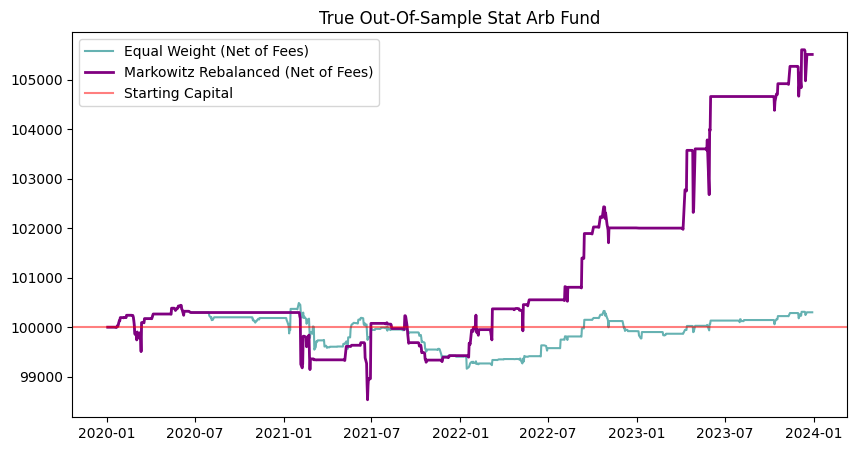

In [9]:
eq_baseline = STARTING_EQUITY + equal_weight_pnl.cumsum()
eq_rebalanced = STARTING_EQUITY + rebalanced_portfolio_pnl.cumsum()

rebal_daily_returns = eq_rebalanced.pct_change().dropna()

annualised_sharpe = (rebal_daily_returns.mean() / rebal_daily_returns.std()) * np.sqrt(252)

running_max = eq_rebalanced.cummax()
drawdown = (eq_rebalanced / running_max) - 1
max_drawdown = drawdown.min() * 100

new_highs = (eq_rebalanced == running_max)
drawdown_streaks = (~new_highs).astype(int).groupby((new_highs).cumsum()).sum()
max_drawdown_duration = drawdown_streaks.max()

print(f"Annualised Sharpe: {annualised_sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2f}%")
print(f"Drawdown Duration: {int(max_drawdown_duration)} days")

plt.figure(figsize=(10, 5))
plt.plot(eq_baseline, label='Equal Weight (Net of Fees)', color='teal', alpha=0.6)
plt.plot(eq_rebalanced, label='Markowitz Rebalanced (Net of Fees)', color='purple', linewidth=2)
plt.axhline(STARTING_EQUITY, color='red', linestyle='-', alpha=0.5, label='Starting Capital')
plt.title("True Out-Of-Sample Stat Arb Fund")
plt.legend()
plt.show()

- **Sharpe ratio:** average return per unit of volatility, annualised by multiplying by √252 (the standard scaling factor for converting daily statistics to annual ones, since variance scales linearly with time under i.i.d. assumptions, so standard deviation scales with the square root of time). A Sharpe of ~1.0+ is generally considered solid for a market-neutral strategy; 0.68 is real but modest.
- **Max drawdown:** the worst peak-to-trough decline in equity — a measure of the single worst pain point an investor would have experienced.
- **Drawdown duration:** how long the equity curve went without setting a new high. This matters independently of drawdown depth — a small but very long drawdown means the strategy went nowhere for a long stretch, which is a different (and often more psychologically punishing) problem than a sharp but brief loss.


# **8. Validation: The Placebo / Permutation Test**

Calculating True Sharpe Ratio (using Real Sectors)...
Real Strategy Sharpe: 0.68

Running Placebo Distribution (50 runs). This may take a minute...


Placebo Runs: 100%|██████████| 50/50 [02:51<00:00,  3.43s/it]


=== FINAL FALSIFICATION RESULTS ===
Real Sharpe Ratio:  0.68
Placebo Avg Sharpe: -0.08
Empirical P-Value:  0.040 (2 out of 50 runs beat the real strategy)


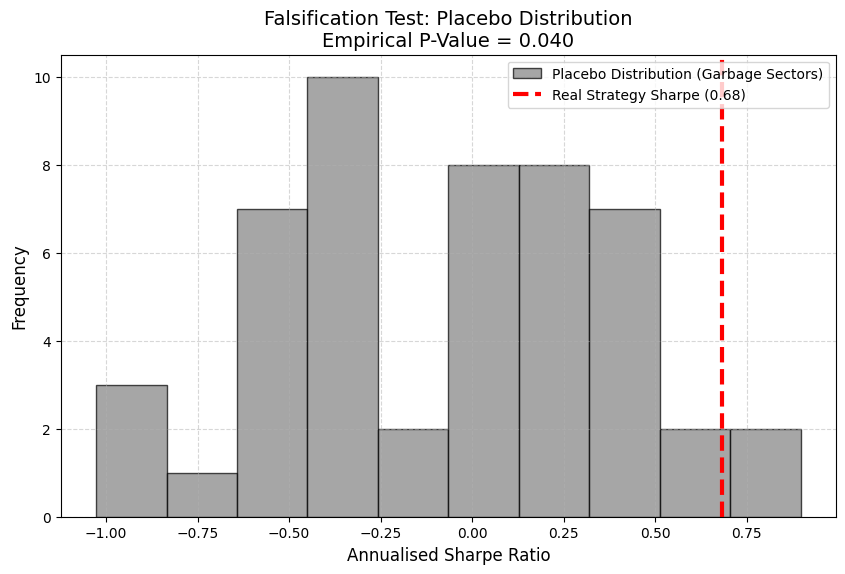

In [10]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# 1. ENCAPSULATE THE ENGINE

def run_pipeline(active_sector_map, is_placebo=False):
    """Runs the full Stat Arb pipeline and returns the Annualised Sharpe Ratio."""

    BENCH_SIZE = 50
    STARTING_EQUITY = 100000
    TOTAL_BUYING_POWER = STARTING_EQUITY

    all_pnl = pd.DataFrame(index=master_data.index)
    portfolio_allocation = pd.DataFrame(False, index=master_data.index, columns=[])

    # A & B: FORMATION AND TRADING
    for i in range(FORMATION_DAYS, len(master_data), TRADING_DAYS):
        formation_data = master_data.iloc[i - FORMATION_DAYS : i]
        end_idx = min(i + TRADING_DAYS, len(master_data))
        trading_index = master_data.index[i : end_idx]
        calc_start_idx = max(0, i - 30)
        calc_data = master_data.iloc[calc_start_idx : end_idx]

        corr_matrix = formation_data.corr()
        mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        high_corr = corr_matrix.where(mask).stack()
        high_corr = high_corr[high_corr > CORR_THRESHOLD]

        # THE CRITICAL FILTER: Uses whatever sector map is passed in
        sector_matched_pairs = [pair for pair in high_corr.index if active_sector_map[pair[0]] == active_sector_map[pair[1]]]

        results_list = []
        for pair in sector_matched_pairs:
            Y_train = formation_data[pair[0]]
            X_train = sm.add_constant(formation_data[pair[1]])
            try:
                model = sm.OLS(Y_train, X_train).fit()
                p_value = adfuller(model.resid)[1]
                if p_value < ADF_P_VALUE:
                    res_series = model.resid
                    res_diff = res_series.diff().dropna()
                    res_lag = res_series.shift(1).dropna()
                    phi = sm.OLS(res_diff, res_lag).fit().params.iloc[0]
                    if phi < 0:
                        half_life = -np.log(2) / phi
                        if half_life < HL_CUTOFF:
                            results_list.append({
                                "Pair": pair, "P-Value": p_value,
                                "Intercept": model.params.iloc[0], "Slope": model.params.iloc[1]
                            })
            except:
                continue

        if not results_list: continue
        results_df = pd.DataFrame(results_list).sort_values(by="P-Value")

        ticker_counts = {}
        top_pairs = []
        for _, row in results_df.iterrows():
            t1, t2 = row["Pair"]
            if ticker_counts.get(t1, 0) < MAX_TICKER_OVERLAP and ticker_counts.get(t2, 0) < MAX_TICKER_OVERLAP:
                top_pairs.append(row)
                ticker_counts[t1] = ticker_counts.get(t1, 0) + 1
                ticker_counts[t2] = ticker_counts.get(t2, 0) + 1
            if len(top_pairs) == BENCH_SIZE: break

        epoch_cooldown = pd.DataFrame(True, index=trading_index, columns=[])
        epoch_pnl = pd.DataFrame(0.0, index=trading_index, columns=[])

        for row in top_pairs:
            t1, t2 = row["Pair"]
            col_name = f"{t1}_{t2}"
            Y_calc = calc_data[t1]
            X_calc = calc_data[t2]
            intercept, slope = row["Intercept"], row["Slope"]

            residuals = Y_calc - (intercept + slope * X_calc)
            rolling_mean = residuals.rolling(window=30).mean()
            rolling_std = residuals.rolling(window=30).std()
            z_score = (residuals - rolling_mean) / rolling_std

            panic_triggered = (z_score > 4.0) | (z_score < -4.0)
            cooldown = panic_triggered.rolling(window=30, min_periods=1).max().astype(bool)
            conditions = [cooldown, (z_score > Z_ENTRY), (z_score < -Z_ENTRY)]
            signals = pd.Series(np.select(conditions, [0, -1, 1], default=0), index=residuals.index)

            combined_price = Y_calc.shift(1) + X_calc.shift(1)
            spread_vol = residuals.diff().rolling(30).std().shift(1)
            vol_scalar = (1.0 / (spread_vol + 1e-6)).clip(0.5, 2.0)

            adjusted_notional = TARGET_NOTIONAL * vol_scalar
            shares_traded = (adjusted_notional / combined_price).fillna(0)

            gross_pnl = residuals.diff() * signals.shift(1) * shares_traded
            fees = (signals * shares_traded).diff().abs() * combined_price * SLIPPAGE_BPS

            epoch_pnl[col_name] = (gross_pnl - fees).loc[trading_index]
            epoch_cooldown[col_name] = cooldown.loc[trading_index]

        epoch_valid = ~epoch_cooldown
        epoch_allocation = epoch_valid & (epoch_valid.cumsum(axis=1) <= 10)

        for col in epoch_pnl.columns:
            if col not in all_pnl.columns:
                all_pnl[col] = 0.0
                portfolio_allocation[col] = False
            all_pnl.loc[trading_index, col] = epoch_pnl[col]
            portfolio_allocation.loc[trading_index, col] = epoch_allocation[col]

    dynamic_pnl_matrix = (all_pnl * portfolio_allocation).iloc[FORMATION_DAYS:]
    portfolio_allocation = portfolio_allocation.iloc[FORMATION_DAYS:]

    # C. MARKOWITZ OPTIMIZATION
    strategy_returns = dynamic_pnl_matrix.div(TARGET_NOTIONAL).dropna(axis=1, how='all')
    strategy_returns = strategy_returns.loc[:, (strategy_returns != 0).any(axis=0)]

    if strategy_returns.empty:
        return 0.0 # Fail-safe if placebo generates absolutely zero pairs

    LOOKBACK_DAYS, REBALANCE_DAYS = 126, 21
    rebalanced_portfolio_pnl = pd.Series(0.0, index=strategy_returns.index)

    # Bootstrap the first 6 months with equal weight
    equal_weight_pnl = strategy_returns.sum(axis=1) * (TOTAL_BUYING_POWER / 10)
    rebalanced_portfolio_pnl.iloc[:LOOKBACK_DAYS] = equal_weight_pnl.iloc[:LOOKBACK_DAYS]

    for i in range(LOOKBACK_DAYS, len(strategy_returns), REBALANCE_DAYS):
        historical_returns = strategy_returns.iloc[i - LOOKBACK_DAYS : i]
        historical_allocation = portfolio_allocation[strategy_returns.columns].iloc[i - LOOKBACK_DAYS : i]

        historical_nan = historical_returns.where(historical_allocation, np.nan)
        active_cols = historical_nan.columns[historical_nan.notna().sum() > 5]
        if len(active_cols) == 0: continue

        active_window = historical_nan[active_cols]
        mu = active_window.mean() * 252
        Sigma = active_window.cov() * 252
        Sigma = Sigma.fillna(0)

        eigvals = np.linalg.eigvalsh(Sigma)
        if eigvals.min() < 1e-8:
            Sigma = Sigma + np.eye(len(Sigma)) * (abs(eigvals.min()) + 1e-6)

        num_active = len(active_cols)
        constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        bounds = tuple((0, 1) for _ in range(num_active))

        optimal_result = minimize(negative_sharpe, num_active * [1. / num_active,],
                                  args=(mu, Sigma), method='SLSQP', bounds=bounds, constraints=constraints)

        end_idx = min(i + REBALANCE_DAYS, len(strategy_returns))
        forward_window = strategy_returns.iloc[i : end_idx]
        for asset_idx, col in enumerate(active_cols):
            rebalanced_portfolio_pnl.iloc[i : end_idx] += forward_window[col] * (optimal_result.x[asset_idx] * TOTAL_BUYING_POWER)

    # D. RETURN THE SHARPE RATIO
    eq_rebalanced = STARTING_EQUITY + rebalanced_portfolio_pnl.cumsum()
    rebal_daily_returns = eq_rebalanced.pct_change().dropna()

    if rebal_daily_returns.std() > 0:
        return (rebal_daily_returns.mean() / rebal_daily_returns.std()) * np.sqrt(252)
    return 0.0


# 2. RUN THE VALIDATION TESTS
NUM_PLACEBO_RUNS = 50

print("Calculating True Sharpe Ratio (using Real Sectors)...")
real_sharpe = run_pipeline(SECTOR_MAP, is_placebo=False)
print(f"Real Strategy Sharpe: {real_sharpe:.2f}\n")

print(f"Running Placebo Distribution ({NUM_PLACEBO_RUNS} runs). This may take a minute...")
placebo_sharpes = []

np.random.seed(123)

for i in tqdm(range(NUM_PLACEBO_RUNS), desc="Placebo Runs"):
    # Randomly shuffle the sector values to break economic reality
    shuffled_sectors = list(SECTOR_MAP.values())
    np.random.shuffle(shuffled_sectors)
    shuffled_map = dict(zip(SECTOR_MAP.keys(), shuffled_sectors))

    # Run the exact same pipeline using the garbage sector map
    p_sharpe = run_pipeline(shuffled_map, is_placebo=True)
    placebo_sharpes.append(p_sharpe)


# 3. CALCULATE EMPIRICAL P-VALUE & PLOT HISTOGRAM

# How many placebo runs matched or beat our real Sharpe?
better_or_equal = sum(1 for s in placebo_sharpes if s >= real_sharpe)
empirical_p_value = better_or_equal / NUM_PLACEBO_RUNS

print(f"\n=== FINAL FALSIFICATION RESULTS ===")
print(f"Real Sharpe Ratio:  {real_sharpe:.2f}")
print(f"Placebo Avg Sharpe: {np.mean(placebo_sharpes):.2f}")
print(f"Empirical P-Value:  {empirical_p_value:.3f} ({better_or_equal} out of {NUM_PLACEBO_RUNS} runs beat the real strategy)")

# Plotting the Histogram
plt.figure(figsize=(10, 6))
plt.hist(placebo_sharpes, bins=10, color='gray', alpha=0.7, edgecolor='black', label='Placebo Distribution (Garbage Sectors)')
plt.axvline(real_sharpe, color='red', linestyle='dashed', linewidth=3, label=f'Real Strategy Sharpe ({real_sharpe:.2f})')

plt.title(f"Falsification Test: Placebo Distribution\nEmpirical P-Value = {empirical_p_value:.3f}", fontsize=14)
plt.xlabel("Annualised Sharpe Ratio", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Concept — falsification testing / permutation tests:** this is one of the most important ideas in quantitative research, and it's a general-purpose tool, not specific to trading. The logic: if your strategy's edge genuinely comes from real sector relationships, then randomly scrambling which stock belongs to which "sector" (while keeping the group sizes identical) should destroy that edge, because the labels no longer correspond to anything economically real — even though every other part of the pipeline (correlation filter, ADF test, half-life filter, Markowitz optimizer) runs completely unchanged.

If the real strategy meaningfully and consistently outperforms this randomized version, that's evidence the specific, economically-motivated structure (real sectors) is adding value — not just that the statistical machinery finds some pattern in any grouping you feed it.

**Why one shuffle isn't enough, and why you need a distribution:** any single random shuffle is just one draw from a huge space of possible relabelings. It could, by chance, land on an unusually good or unusually bad placebo outcome. Running it 50+ times and building a distribution of placebo Sharpe ratios lets you ask a much more precise question: "where does my real result fall relative to the range of outcomes I'd expect from pure chance?" — which is exactly what an empirical p-value answers:

empirical_p_value = (number of placebo runs that beat the real result) / (total placebo runs)

This is a non-parametric, distribution-free significance test — instead of assuming your data follows some known statistical distribution and computing a p-value from a formula, you directly build the "what would this look like under the null hypothesis" distribution by brute-force simulation, and see where your actual result lands in it. It's a more robust and more intuitive method than most textbook hypothesis tests, at the cost of needing to rerun the whole pipeline many times (computationally expensive but conceptually simple).



# **9. Honest Summary of Where This Landed**

- The naive version (no sector filter, no formation/trading split, flat fees) showed no real edge once look-ahead bias and realistic costs were addressed.
- Adding sector-matching, a stricter cointegration threshold, and a half-life filter revealed a real (if modest) net-of-cost edge: ~5.5% over 4 years unlevered, Sharpe ≈ 0.68.
- A placebo/permutation test suggested this edge is not purely a statistical artifact of the screening machinery — real sector structure outperformed randomly shuffled sector structure in 48 of 50 trials (empirical p ≈ 0.04).
- That said, p ≈ 0.04 from only 50 trials is a coarse, borderline estimate, and two placebo draws actually beat the real result — so "suggestive, not confirmed" is the fair characterization, not "proven."
- Known, documented limitations that remain: survivorship bias (only currently-listed large caps were tested), possible over-tuning of filter thresholds to this specific historical window, and cross-epoch position discontinuity at formation-window boundaries.
